In [170]:
import json
import os
from pathlib import Path
from unicodedata import category
import pandas as pd
import duckdb
import statistics
import pandas as pd
import duckdb
import numpy as np
import functools
import pyro
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns




In [171]:
import matplotlib
matplotlib.rc('font', family='Arial Unicode Ms')

In [172]:
df_sess = pd.read_parquet('../../data/processed/irt_session.parquet')
df_sess['section_name']  = df_sess['section_name']
df_sess.value_counts('session_id')

LENGTH_LIMIT = 12
WINDOW_SIZE = 5
# 限制answer length 大於12 (6個ability)
# [0,1,2,3,4,5,6,7,8,9,10,11]
df_sess : pd.DataFrame = df_sess[df_sess["answer_length"] >= LENGTH_LIMIT]

# 先按 user + start_time 排好時間順序
df_sess : pd.DataFrame = df_sess.sort_values(["user_id", "start_time"])


df_sess['difficulty_level_chunk'] = df_sess['difficulty_level'].apply(lambda lis :  [lis[i:i+WINDOW_SIZE] for i in range(0,LENGTH_LIMIT-WINDOW_SIZE+1)] )
df_sess['question_id_chunk'] =      df_sess['question_id'].apply(lambda lis :        [lis[i:i+WINDOW_SIZE] for i in range(0,LENGTH_LIMIT-WINDOW_SIZE+1)] )
df_sess['is_correct_chunk'] =       df_sess['is_correct'].apply(lambda lis :        [lis[i:i+WINDOW_SIZE] for i in range(0,LENGTH_LIMIT-WINDOW_SIZE+1)] )
df_sess.user_id.nunique()

4678

In [173]:
df_sess

,index,user_id,session_id,section_name,gamecharacter_id_mode,is_correct,difficulty_level,question_id,created_at,answer,book_volume_grade,time_diff,start_time,end_time,session_length,answer_length,difficulty_level_chunk,question_id_chunk,is_correct_chunk
40242,40242,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]","[2, 2, 2, 3, 2, 3, 1, 2, 2, 1, 3, 3, 1, 2, 1, 3]","[-2034665883776618604, 8275106735268333608, -6...","[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...","[[""B""], [""B""], [""D""], [""A""], [""B""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[0, 30, 37, 144, 55, 120, 24, 24, 33, 56, 31, ...",2023-09-27 08:28:25,2023-09-27 08:41:25,780,16,"[[2, 2, 2, 3, 2], [2, 2, 3, 2, 3], [2, 3, 2, 3...","[[-2034665883776618604, 8275106735268333608, -...","[[0, 1, 0, 1, 1], [1, 0, 1, 1, 0], [0, 1, 1, 0..."
38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 1, 3, 2, 1, 3, 2, 2, 1, 3, 1, 3, 1, 3, 1, ...","[1546381573830368031, -6292240633515883796, -5...","[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...","[[""B""], [""C""], [""A""], [""A""], [""A""], [""A""], [""B...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[775579, 18, 50, 60, 39, 70, 36, 57, 19, 88, 4...",2023-10-06 08:07:44,2023-10-06 08:30:43,1379,28,"[[2, 1, 3, 2, 1], [1, 3, 2, 1, 3], [3, 2, 1, 3...","[[1546381573830368031, -6292240633515883796, -...","[[1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1..."
3694,3694,-9221365525345808910,2.0,2+3 因數與公因數、倍數與公倍數,3047773802229627867,"[1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...","[1, 1, 3, 1, 1, 2, 1, 2, 3, 2, 2, 1, 1, 1, 2, ...","[-7367281277998551315, -6027827608169220599, 1...","[2023-10-13T08:15:51.000000, 2023-10-13T08:16:...","[[""A""], [""C""], [""A""], [""A""], [""D""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[603290, 51, 34, 28, 91, 38, 18, 30, 41, 60, 4...",2023-10-13 08:15:51,2023-10-13 08:40:01,1450,28,"[[1, 1, 3, 1, 1], [1, 3, 1, 1, 2], [3, 1, 1, 2...","[[-7367281277998551315, -6027827608169220599, ...","[[1, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0..."
3695,3695,-9221365525345808910,3.0,2+3 因數與公因數、倍數與公倍數,3047773802229627867,"[0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, ...","[3, 3, 1, 1, 2, 3, 1, 1, 1, 2, 2, 2, 2, 3, 2, ...","[-995415077368945423, -318206443770914157, 268...","[2023-10-25T08:20:15.000000, 2023-10-25T08:21:...","[[""B""], [""D""], [""A""], [""C""], [""A""], [""D""], [""A...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[1035614, 103, 69, 49, 74, 28, 19, 73, 12, 13,...",2023-10-25 08:20:15,2023-10-25 08:37:52,1057,31,"[[3, 3, 1, 1, 2], [3, 1, 1, 2, 3], [1, 1, 2, 3...","[[-995415077368945423, -318206443770914157, 26...","[[0, 0, 1, 0, 1], [0, 1, 0, 1, 0], [1, 0, 1, 0..."
1601,1601,-9221365525345808910,6.0,2+3 因數與公因數、倍數與公倍數,3047773802229627867,"[1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1]","[1, 1, 1, 2, 1, 1, 1, 1, 2, 3, 2, 2, 1, 1, 1]","[3347446545753250720, 1823105465577305876, 539...","[2023-12-14T08:29:40.000000, 2023-12-14T08:30:...","[[""A""], [""A""], [""D""], [""A""], [""A""], [""B""], [""A...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[690703, 29, 68, 13, 29, 62, 79, 14, 158, 67, ...",2023-12-14 08:29:40,2023-12-14 08:40:32,652,15,"[[1, 1, 1, 2, 1], [1, 1, 2, 1, 1], [1, 2, 1, 1...","[[3347446545753250720, 1823105465577305876, 53...","[[1, 1, 0, 0, 1], [1, 0, 0, 1, 0], [0, 0, 1, 0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143576,880,9223131428943628703,6.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1]","[2, 2, 2, 3, 1, 2, 1, 2, 3, 1, 1, 1, 1]","[4401059293076573266, 4401059293076573266, -66...","[2024-02-10T17:41:44.000000, 2024-02-10T17:42:...","[[""B""], [""B""], [""A""], [""A""], [""B""], [""A""], [""A...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[45418, 38, 11, 21, 318, 60, 203, 29, 46, 86, ...",2024-02-1

In [174]:

df_sess = df_sess.explode(['difficulty_level_chunk','question_id_chunk','is_correct_chunk'])

df_sess['chunk_order_'] = 1
df_sess['chunk_order'] = df_sess.groupby(['user_id','section_name','session_id'])['chunk_order_'].cumcount()

In [175]:
df_sess['is_correct'] = df_sess['is_correct_chunk']
df_sess['difficulty_level'] = df_sess['difficulty_level_chunk']
df_sess['question_id'] = df_sess['question_id_chunk']
df_sess['block_idx'] = df_sess['chunk_order']
df_sess.reset_index(inplace=True)
df_sess.head()

,level_0,index,user_id,session_id,section_name,gamecharacter_id_mode,is_correct,difficulty_level,question_id,created_at,...,start_time,end_time,session_length,answer_length,difficulty_level_chunk,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx
0,40242,40242,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[0, 1, 0, 1, 1]","[2, 2, 2, 3, 2]","[-2034665883776618604, 8275106735268333608, -6...","[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,2023-09-27 08:28:25,2023-09-27 08:41:25,780,16,"[2, 2, 2, 3, 2]","[-2034665883776618604, 8275106735268333608, -6...","[0, 1, 0, 1, 1]",1,0,0
1,40242,40242,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[1, 0, 1, 1, 0]","[2, 2, 3, 2, 3]","[8275106735268333608, -6151073623966115724, 89...","[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,2023-09-27 08:28:25,2023-09-27 08:41:25,780,16,"[2, 2, 3, 2, 3]","[8275106735268333608, -6151073623966115724, 89...","[1, 0, 1, 1, 0]",1,1,1
2,40242,40242,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[0, 1, 1, 0, 1]","[2, 3, 2, 3, 1]","[-6151073623966115724, 8976889308967464605, 16...","[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,2023-09-27 08:28:25,2023-09-27 08:41:25,780,16,"[2, 3, 2, 3, 1]","[-6151073623966115724, 8976889308967464605, 16...","[0, 1, 1, 0, 1]",1,2,2
3,40242,40242,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[1, 1, 0, 1, 1]","[3, 2, 3, 1, 2]","[8976889308967464605, 1600138149171310036, 141...","[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,2023-09-27 08:28:25,2023-09-27 08:41:25,780,16,"[3, 2, 3, 1, 2]","[8976889308967464605, 1600138149171310036, 141...","[1, 1, 0, 1, 1]",1,3,3
4,40242,40242,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[1, 0, 1, 1, 0]","[2, 3, 1, 2, 2]","[1600138149171310036, 141690302974453717, 3279...","[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,2023-09-27 08:28:25,2023-09-27 08:41:25,780,16,"[2, 3, 1, 2, 2]","[1600138149171310036, 141690302974453717, 3279...","[1, 0, 1, 1, 0]",1,4,4


In [176]:
df_sess['qlen'] = df_sess['question_id'].apply(lambda x: True if len(x) == 5 else False)
df_sess = df_sess.query('qlen == True')

In [177]:

cols_to_explode = [
    "question_id",
    "is_correct",
    "difficulty_level_chunk",
]

df_long = df_sess.explode(cols_to_explode, ignore_index=True)
df_long["difficulty"] = df_long["difficulty_level"]
df_long["hash_section_name"] = df_long['section_name'].apply(hash)

In [178]:
df_long["subject_id"] = (
    df_long["user_id"].astype(str)
    + "_sec"
    + df_long['hash_section_name'].astype(str)
    + "_b"
    + df_long["chunk_order"].astype(str)
    +"_sess_id"
    + df_long['session_id'].astype(str)
)

In [179]:
df_long["is_correct"] = df_long["is_correct"].astype(int)

# 題目、subject（受試者） 的 index
item_ids = df_long["question_id"].astype(str).unique()
subj_ids = df_long["subject_id"].astype(str).unique()



item_index = {qid: i for i, qid in enumerate(item_ids)}
subj_index = {sid: i for i, sid in enumerate(subj_ids)}

# 轉成 numpy array
items = df_long["question_id"].astype(str).map(item_index).to_numpy()
subjects = df_long["subject_id"].astype(str).map(subj_index).to_numpy()
responses = df_long["is_correct"].to_numpy().astype(np.float32)

num_items = len(item_ids)
num_subjects = len(subj_ids)

print(f"num of items: {num_items}, num of subjects (tester): {num_subjects}")

num of items: 9795, num of subjects (tester): 131008


In [180]:
from py_irt.models.one_param_logistic import OneParamLog

import torch
from py_irt.models.one_param_logistic import OneParamLog

# 轉成 torch tensor（這是 Pyro 要的）
models_t    = torch.tensor(subjects,  dtype=torch.long)     # 每筆作答的 subject index
items_t     = torch.tensor(items,     dtype=torch.long)     # 每筆作答的 item index
responses_t = torch.tensor(responses, dtype=torch.float32)  # 0/1

num_items     = int(max(items) + 1)
num_subjects  = int(max(subjects) + 1)

# 初始化 1PL 模型（Rasch）
model = OneParamLog(
    priors="hierarchical",
    num_items=num_items,
    num_subjects=num_subjects,
    verbose=True,
    device="cpu",
)

trace=model.fit(
    models=models_t,
    items=items_t,
    responses=responses_t,
    num_epochs=10000,
)


[epoch 0001] loss: 1130511731.4129
[epoch 0101] loss: 1195906.3676
[epoch 0201] loss: 1356111.4123
[epoch 0301] loss: 780293.4893
[epoch 0401] loss: 961598.4552
[epoch 0501] loss: 1065522.4140
[epoch 0601] loss: 957593.4655
[epoch 0701] loss: 1176265.8476
[epoch 0801] loss: 584021.4240
[epoch 0901] loss: 1278902.2378
[epoch 1001] loss: 625053.3958
[epoch 1101] loss: 604151.0380
[epoch 1201] loss: 605123.4316
[epoch 1301] loss: 515528.4863
[epoch 1401] loss: 805973.4356
[epoch 1501] loss: 690463.0436
[epoch 1601] loss: 771244.5049
[epoch 1701] loss: 639221.0862
[epoch 1801] loss: 685640.7620
[epoch 1901] loss: 747848.3404
[epoch 2001] loss: 1156815.8281
[epoch 2101] loss: 603217.8902
[epoch 2201] loss: 544994.6460
[epoch 2301] loss: 793899.7908
[epoch 2401] loss: 537458.2145
[epoch 2501] loss: 535867.9941
[epoch 2601] loss: 651441.5498
[epoch 2701] loss: 790002.8781
[epoch 2801] loss: 436159.6520
[epoch 2901] loss: 566052.2045
[epoch 3001] loss: 479782.7517
[epoch 3101] loss: 1088514.31

In [181]:
param_store = pyro.get_param_store()
print(param_store.keys())

# 假設 ability 叫 "theta_loc"，難度叫 "b_loc"（名字要以你印出來的為準）
theta_mean = param_store["loc_ability"].detach().cpu().numpy()
b_mean     = param_store["loc_diff"].detach().cpu().numpy()

dict_keys(['loc_mu_b', 'scale_mu_b', 'loc_mu_theta', 'scale_mu_theta', 'alpha_b', 'beta_b', 'alpha_theta', 'beta_theta', 'loc_ability', 'scale_ability', 'loc_diff', 'scale_diff'])


In [182]:
inv_subj_index = {v: k for k, v in subj_index.items()}

theta_df = (
    pd.DataFrame({
        "subject_idx": np.arange(num_subjects),
        "theta": theta_mean,
    })
    .assign(subject_id=lambda d: d["subject_idx"].map(inv_subj_index))
)



df_sess_with_theta = df_long.drop_duplicates(subset=['subject_id'])
df_sess_with_theta = df_sess_with_theta.drop(labels=['level_0','index','is_correct','difficulty_level_chunk'],axis = 1)



In [183]:
con = duckdb.connect()

con.register("theta_df", theta_df)
con.register("df_long", df_sess_with_theta)

theta_df_merged = con.execute("""
SELECT t.*, d.*
FROM theta_df t
LEFT JOIN df_long d
  ON t.subject_id = d.subject_id
""").df()

con.close()
theta_df = theta_df_merged

In [184]:
df_sess_with_theta

,user_id,session_id,section_name,gamecharacter_id_mode,difficulty_level,question_id,created_at,answer,book_volume_grade,time_diff,...,answer_length,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id
0,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 2, 2, 3, 2]",-2034665883776618604,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...","[[""B""], [""B""], [""D""], [""A""], [""B""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[0, 30, 37, 144, 55, 120, 24, 24, 33, 56, 31, ...",...,16,"[-2034665883776618604, 8275106735268333608, -6...","[0, 1, 0, 1, 1]",1,0,0,True,"[2, 2, 2, 3, 2]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
5,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 2, 3, 2, 3]",8275106735268333608,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...","[[""B""], [""B""], [""D""], [""A""], [""B""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[0, 30, 37, 144, 55, 120, 24, 24, 33, 56, 31, ...",...,16,"[8275106735268333608, -6151073623966115724, 89...","[1, 0, 1, 1, 0]",1,1,1,True,"[2, 2, 3, 2, 3]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
10,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 3, 2, 3, 1]",-6151073623966115724,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...","[[""B""], [""B""], [""D""], [""A""], [""B""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[0, 30, 37, 144, 55, 120, 24, 24, 33, 56, 31, ...",...,16,"[-6151073623966115724, 8976889308967464605, 16...","[0, 1, 1, 0, 1]",1,2,2,True,"[2, 3, 2, 3, 1]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
15,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[3, 2, 3, 1, 2]",8976889308967464605,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...","[[""B""], [""B""], [""D""], [""A""], [""B""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[0, 30, 37, 144, 55, 120, 24, 24, 33, 56, 31, ...",...,16,"[8976889308967464605, 1600138149171310036, 141...","[1, 1, 0, 1, 1]",1,3,3,True,"[3, 2, 3, 1, 2]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
20,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 3, 1, 2, 2]",1600138149171310036,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...","[[""B""], [""B""], [""D""], [""A""], [""B""], [""A""], [""C...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[0, 30, 37, 144, 55, 120, 24, 24, 33, 56, 31, ...",...,16,"[1600138149171310036, 141690302974453717, 3279...","[1, 0, 1, 1, 0]",1,4,4,True,"[2, 3, 1, 2, 2]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655015,9223131428943628703,7.0,8 整數四則運算,7923019900804306903,"[2, 2, 2, 2, 2]",2215552269525252949,"[2024-02-13T04:22:18.000000, 2024-02-13T04:24:...","[[""A""], [""C""], [""D""], [""D""], [""D""], [""D""], [""D...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[210407, 123, 496, 212, 106, 20, 12, 245, 76, ...",...,15,"[2215552269525252949, 2215552269525252949, 221...","[0, 0, 1, 1, 1]",1,3,3,True,"[2, 2, 2, 2, 2]",6477365964703788691,9223131428943628703_sec6477365964703788691_b3_...
655020,9223131428943628703,7.0,8 整數四則運算,7923019900804306903,"[2, 2, 2, 2, 1]",2215552269525252949,"[2024-02-13T04:22:18.000000, 2024-02-13T04:24:...","[[""A""], [""C""], [""D""], [""D""], [""D""], [""D""], [""D...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[210407, 123, 496, 212, 106, 20, 12, 245, 76, ...",...,15,"[2215552269525252949, 2215552269525252949, 221...","[0, 1, 1, 1, 1]",1,4,4,True,"[2, 2, 2, 2, 1]",6477365964703788691,9223131428943628703_sec6477365964703788691_b4_...
655025,9223131428943628703,7.0,8 整數四則運算,7923019900804306903,"[2, 2, 2, 1, 1]",2215552269525252949,"[2024-02-13T04:22:18.000000, 2024-02-13T04:24:...","[[""A""], [""C""], [""D""], [""D""], [""D""], [""D""], [""D..

In [185]:
theta_df

,subject_idx,theta,subject_id,user_id,session_id,section_name,gamecharacter_id_mode,difficulty_level,question_id,created_at,...,answer_length,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id_1
0,0,-0.075646,-9221365525345808910_sec-3779578560606472282_b...,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 2, 2, 3, 2]",-2034665883776618604,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,16,"[-2034665883776618604, 8275106735268333608, -6...","[0, 1, 0, 1, 1]",1,0,0,True,"[2, 2, 2, 3, 2]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
1,1,0.054245,-9221365525345808910_sec-3779578560606472282_b...,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 2, 3, 2, 3]",8275106735268333608,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,16,"[8275106735268333608, -6151073623966115724, 89...","[1, 0, 1, 1, 0]",1,1,1,True,"[2, 2, 3, 2, 3]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
2,2,0.042369,-9221365525345808910_sec-3779578560606472282_b...,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 3, 2, 3, 1]",-6151073623966115724,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,16,"[-6151073623966115724, 8976889308967464605, 16...","[0, 1, 1, 0, 1]",1,2,2,True,"[2, 3, 2, 3, 1]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
3,3,0.191712,-9221365525345808910_sec-3779578560606472282_b...,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[3, 2, 3, 1, 2]",8976889308967464605,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,16,"[8976889308967464605, 1600138149171310036, 141...","[1, 1, 0, 1, 1]",1,3,3,True,"[3, 2, 3, 1, 2]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
4,4,-0.708745,-9221365525345808910_sec-3779578560606472282_b...,-9221365525345808910,1.0,1 小數的加減,3047773802229627867,"[2, 3, 1, 2, 2]",1600138149171310036,"[2023-09-27T08:28:25.000000, 2023-09-27T08:28:...",...,16,"[1600138149171310036, 141690302974453717, 3279...","[1, 0, 1, 1, 0]",1,4,4,True,"[2, 3, 1, 2, 2]",-3779578560606472282,-9221365525345808910_sec-3779578560606472282_b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131003,102395,-0.533372,5206338333987857875_sec6537886305253772323_b3_...,5206338333987857875,6.0,5 異分母分數的加減,-7715527808129691612,"[2, 1, 2, 3, 2]",62979563642936096,"[2021-08-09T15:04:08.000000, 2021-08-09T15:04:...",...,20,"[62979563642936096, 145583118144198308, -37650...","[0, 1, 0, 0, 1]",1,3,3,True,"[2, 1, 2, 3, 2]",6537886305253772323,5206338333987857875_sec6537886305253772323_b3_...
131004,102396,-0.688995,5206338333987857875_sec6537886305253772323_b4_...,5206338333987857875,6.0,5 異分母分數的加減,-7715527808129691612,"[1, 2, 3, 2, 2]",145583118144198308,"[2021-08-09T15:04:08.000000, 2021-08-09T15:04:...",...,20,"[145583118144198308, -3765090310643933498, -57...","[1, 0, 0, 1, 0]",1,4,4,True,"[1, 2, 3, 2, 2]",6537886305253772323,5206338333987857875_sec6537886305253772323_b4_...
131005,102397,-1.305183,5206338333987857875_sec6537886305253772323_b5_...,5206338333987857875,6.0,5 異分母分數的加減,-7715527808129691612,"[2, 3, 2, 2, 1]",-3765090310643933498,"[2021-08-09T15:04:08.000000, 2021-08-09T15:04:...",...,20,"[-3765090310643933498, -5741188271616336503, -...","[0, 0, 1, 0, 0]",1,5,5,True,"[2, 3, 2, 2, 1]",6537886305253772323,5206338333987857875_sec6537886305253772323_b5_...
131006,102398,-0.322254,5206338333987857875_sec6537886305253772323_b6_...,5206338333987857875,6.0,5 異分母分數的加減,-7715527808129691612,"[3, 2, 2, 1, 1]",-5741188271616336503,"[2021-08-09T15:04:08.000000, 2021-08-09T15:04:...",...,20,"[-5741188271616336503, -8773929494461336941, -...","[0, 1, 0, 0, 1]",1,6,6,True,"[3, 2, 2, 1, 1]",6537886305253772323,5206338333987857875_sec6537886305253772323_b6_...


In [186]:
tmp = theta_df.query('answer_length >= 12').copy()

wide = (tmp
        .pivot(index=['user_id','section_name','session_id'], columns='block_idx', values='theta')
        .rename(columns={0:'b0',
                         1:'b1',
                         2:'b2',
                         3:'b3',
                         4:'b4',
                         5:'b5',
                         6:'b6',
                         7:'b7'
                         })
        .reset_index()
       )[['user_id','section_name','session_id','b0','b1','b2','b3','b4','b5','b6','b7']]

In [187]:
wide

block_idx,user_id,section_name,session_id,b0,b1,b2,b3,b4,b5,b6,b7
0,-9221365525345808910,1 小數的加減,1.0,-0.075646,0.054245,0.042369,0.191712,-0.708745,-0.285280,0.497531,0.559409
1,-9221365525345808910,1 小數的加減,2.0,1.147148,1.129656,1.138206,1.289608,1.540774,1.621322,1.065020,1.129913
2,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,2.0,-1.072209,-2.393836,-1.452281,-1.012027,-0.472358,-0.255596,0.585175,0.359574
3,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,3.0,-0.760635,-0.769055,-0.123707,-0.704911,-0.384571,-0.433423,0.302368,-0.007292
4,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,6.0,-0.671193,-0.619068,-1.180952,-0.795837,-0.219799,-0.090374,-0.353383,0.861197
...,...,...,...,...,...,...,...,...,...,...,...
16371,9223131428943628703,1 多位小數與加減,5.0,-0.664569,0.474044,0.840101,1.243689,1.276010,1.047384,1.430097,-0.094939
16372,9223131428943628703,1 多位小數與加減,6.0,-0.353958,-0.516198,-0.505498,-0.071945,0.479433,0.866546,0.533231,0.885163
16373,9223131428943628703,2+3 因數與公因數、倍數與公倍數,6.0,0.413991,0.811646,1.336598,1.506880,0.336040,0.213029,0.114521,-0.860692
16374,9223131428943628703,2+3 因數與公因數、倍數與公倍數,8.0,-1.305861,-1.676604,-0.915559,-0.470542,0.383902,1.126456,0.718407,1.162418


In [188]:
wide['ability_diff'] = wide.apply(lambda row: [row[f'b{idx+1}'] - row[f'b{idx}'] for idx in range(0,7)],axis = 1)

In [189]:
splite_diff = pd.DataFrame(wide['ability_diff'].to_list()).add_prefix('ability_diff_')
wide = pd.concat([wide.drop('ability_diff',axis = 1),splite_diff],axis= 1)

# define the improvement

In [190]:
thresholds_of_improve = 6 # [0,7]/7
wide['is_improve'] = wide.apply(lambda row :
                                 [(True if row[f'ability_diff_{idx}'] > 0 else False )
                                  for idx in range(7)].count(True)
                                 >= thresholds_of_improve,
                                 axis = 1)
wide

,user_id,section_name,session_id,b0,b1,b2,b3,b4,b5,b6,b7,ability_diff_0,ability_diff_1,ability_diff_2,ability_diff_3,ability_diff_4,ability_diff_5,ability_diff_6,is_improve
0,-9221365525345808910,1 小數的加減,1.0,-0.075646,0.054245,0.042369,0.191712,-0.708745,-0.285280,0.497531,0.559409,0.129891,-0.011877,0.149343,-0.900456,0.423465,0.782811,0.061878,False
1,-9221365525345808910,1 小數的加減,2.0,1.147148,1.129656,1.138206,1.289608,1.540774,1.621322,1.065020,1.129913,-0.017492,0.008549,0.151402,0.251166,0.080548,-0.556302,0.064893,False
2,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,2.0,-1.072209,-2.393836,-1.452281,-1.012027,-0.472358,-0.255596,0.585175,0.359574,-1.321627,0.941555,0.440254,0.539668,0.216762,0.840771,-0.225601,False
3,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,3.0,-0.760635,-0.769055,-0.123707,-0.704911,-0.384571,-0.433423,0.302368,-0.007292,-0.008421,0.645348,-0.581204,0.320340,-0.048852,0.735791,-0.309660,False
4,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,6.0,-0.671193,-0.619068,-1.180952,-0.795837,-0.219799,-0.090374,-0.353383,0.861197,0.052124,-0.561884,0.385115,0.576039,0.129425,-0.263009,1.214579,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16371,9223131428943628703,1 多位小數與加減,5.0,-0.664569,0.474044,0.840101,1.243689,1.276010,1.047384,1.430097,-0.094939,1.138613,0.366058,0.403588,0.032320,-0.228626,0.382713,-1.525036,False
16372,9223131428943628703,1 多位小數與加減,6.0,-0.353958,-0.516198,-0.505498,-0.071945,0.479433,0.866546,0.533231,0.885163,-0.162240,0.010700,0.433552,0.551378,0.387114,-0.333315,0.351932,False
16373,9223131428943628703,2+3 因數與公因數、倍數與公倍數,6.0,0.413991,0.811646,1.336598,1.506880,0.336040,0.213029,0.114521,-0.860692,0.397655,0.524952,0.170282,-1.170840,-0.123011,-0.098508,-0.975213,False
16374,9223131428943628703,2+3 因數與公因數、倍數與公倍數,8.0,-1.305861,-1.676604,-0.915559,-0.470542,0.383902,1.126456,0.718407,1.162418,-0.370743,0.761045,0.445017,0.854444,0.742554,-0.408049,0.444011,False


In [191]:
np.mean(wide.is_improve.astype(int))

0.044088910600879334

In [192]:
improve_df = wide.groupby('user_id').agg(
    Num_of_section = ('is_improve', 'count'),
    Num_of_improve = ('is_improve', lambda lis: sum(1 for _ in lis if _ > 0))
).reset_index()

In [193]:
improve_df.Num_of_section.value_counts()

Num_of_section
1      2093
2       870
3       467
4       338
5       192
6       141
7       115
8        74
9        69
12       50
10       46
11       46
13       24
15       22
14       18
16       14
17       13
18        8
21        8
22        7
23        6
19        6
24        5
39        4
20        4
29        3
27        3
26        3
25        3
46        2
28        2
52        2
33        2
30        2
61        1
243       1
69        1
53        1
58        1
331       1
36        1
90        1
43        1
31        1
47        1
32        1
62        1
35        1
41        1
56        1
Name: count, dtype: int64

Text(0.5, 0, 'Percentile of improve')

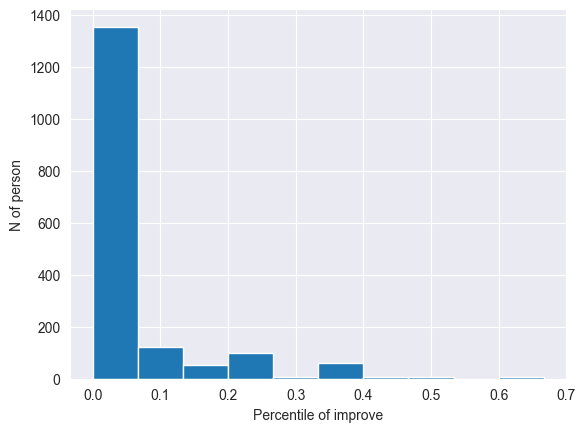

In [194]:

improve_df.loc[:,'ratio_of_improvement'] = improve_df.apply(lambda row : row['Num_of_improve']/row['Num_of_section'],axis = 1)
improve_df.query('Num_of_section > 2')['ratio_of_improvement'].hist(bins = 10)
plt.ylabel('N of person')
plt.xlabel('Percentile of improve')


<Axes: xlabel='ratio_of_improvement', ylabel='Density'>

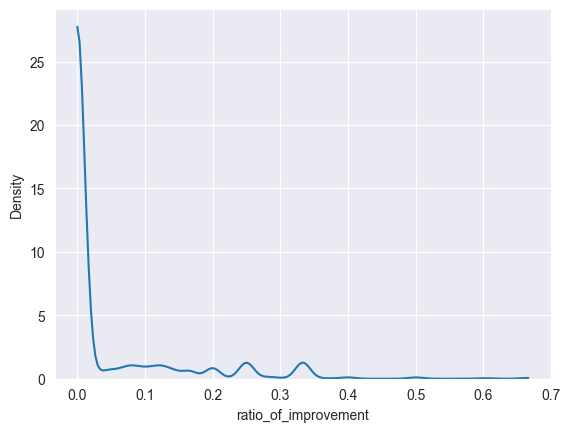

In [195]:
sns.kdeplot(x=improve_df.query('Num_of_section > 2')['ratio_of_improvement'],bw_adjust=.5,cut=0)  # 疊在同圖

<Axes: xlabel='ratio_of_improvement', ylabel='Proportion'>

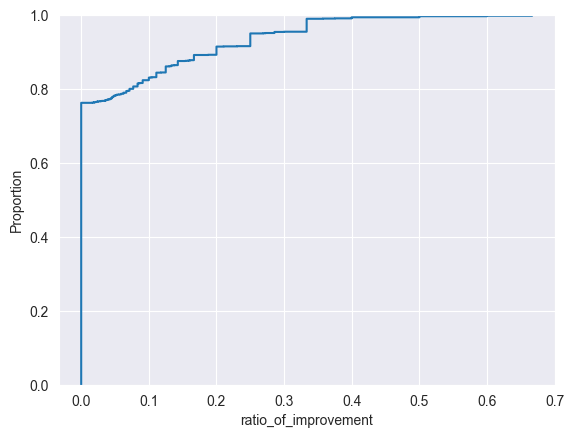

In [196]:
sns.ecdfplot(x=improve_df.query(' Num_of_section > 2')['ratio_of_improvement'])

<Axes: xlabel='Num_of_section', ylabel='ratio_of_improvement'>

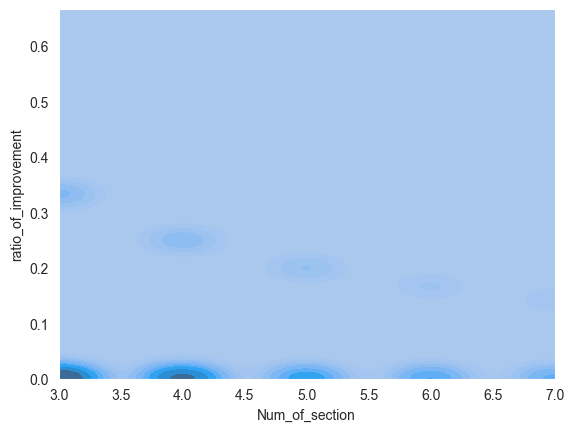

In [197]:
sns.kdeplot(improve_df.query('8 > Num_of_section > 2'),y='ratio_of_improvement',x='Num_of_section',bw_adjust=0.5,cut=0,fill=True,thresh=0)

In [198]:
import scipy as sp
avg_improve = np.mean(wide.is_improve.astype(int))
# binominal approach under p < 0.1
p_value = .1
improve_df['is_improver'] = improve_df.apply(
    lambda row: np.nan if row['Num_of_section'] < 3
        else
            (True if sp.stats.binom.cdf( n = row['Num_of_section'],p = avg_improve, k = row['Num_of_improve']) > (1 - p_value)
            else
                False),
    axis = 1)


In [199]:
improve_df.query("Num_of_section > 2").value_counts('is_improver')

is_improver
False    1383
True      332
Name: count, dtype: int64

In [200]:
person_improve_df = theta_df.copy()
person_improve_df = person_improve_df.groupby(['user_id', 'section_name','session_id'], as_index=False).agg(
    session_id=('session_id', 'first'),
    thetas=('theta', list),
    ans_length = ('answer_length','first'),
    total_time = ('time_diff','first'),
    first18_time = ('time_diff','first' ),
    start_time = ('start_time','first'),
    end_time = ('end_time','first'),
)
person_improve_df['total_time'] = person_improve_df['total_time'].apply(lambda lis:lis[1:])
person_improve_df['first18_time'] = person_improve_df['first18_time'].apply(lambda lis:lis[1:18])
person_improve_df['improve'] = person_improve_df['thetas'].apply(lambda lis: lis[5] - lis[0])
person_improve_df['avg_time12'] = person_improve_df['first18_time'].apply(lambda lis: lis.mean() / 12)
person_improve_df['avg_time'] = person_improve_df.apply(lambda row : row['total_time'].mean() / (row['ans_length'] - 1), axis = 1)
person_improve_df['start_time'] = pd.to_datetime(person_improve_df['start_time'])
person_improve_df['end_time'] = pd.to_datetime(person_improve_df['end_time'])

In [201]:
person_improve_df

,user_id,section_name,session_id,thetas,ans_length,total_time,first18_time,start_time,end_time,improve,avg_time12,avg_time
0,-9221365525345808910,1 小數的加減,1.0,"[-0.07564564049243927, 0.054245442152023315, 0...",16,"[30, 37, 144, 55, 120, 24, 24, 33, 56, 31, 63,...","[30, 37, 144, 55, 120, 24, 24, 33, 56, 31, 63,...",2023-09-27 08:28:25,2023-09-27 08:41:25,-0.209634,4.333333,3.466667
1,-9221365525345808910,1 小數的加減,2.0,"[1.1471483707427979, 1.129656434059143, 1.1382...",28,"[18, 50, 60, 39, 70, 36, 57, 19, 88, 43, 70, 5...","[18, 50, 60, 39, 70, 36, 57, 19, 88, 43, 70, 5...",2023-10-06 08:07:44,2023-10-06 08:30:43,0.474174,3.911765,1.891632
2,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,2.0,"[-1.0722087621688843, -2.3938357830047607, -1....",28,"[51, 34, 28, 91, 38, 18, 30, 41, 60, 43, 99, 1...","[51, 34, 28, 91, 38, 18, 30, 41, 60, 43, 99, 1...",2023-10-13 08:15:51,2023-10-13 08:40:01,0.816612,4.029412,1.989026
3,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,3.0,"[-0.7606346011161804, -0.769055187702179, -0.1...",31,"[103, 69, 49, 74, 28, 19, 73, 12, 13, 16, 22, ...","[103, 69, 49, 74, 28, 19, 73, 12, 13, 16, 22, ...",2023-10-25 08:20:15,2023-10-25 08:37:52,0.327212,3.715686,1.174444
4,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,6.0,"[-0.6711925268173218, -0.619068443775177, -1.1...",15,"[29, 68, 13, 29, 62, 79, 14, 158, 67, 15, 69, ...","[29, 68, 13, 29, 62, 79, 14, 158, 67, 15, 69, ...",2023-12-14 08:29:40,2023-12-14 08:40:32,0.580819,3.880952,3.326531
...,...,...,...,...,...,...,...,...,...,...,...,...
16371,9223131428943628703,1 多位小數與加減,5.0,"[-0.6645689606666565, 0.47404366731643677, 0.8...",15,"[18, 183, 34, 36, 82, 62, 289, 116, 86, 181, 1...","[18, 183, 34, 36, 82, 62, 289, 116, 86, 181, 1...",2024-02-10 17:44:05,2024-02-10 18:05:46,1.711953,7.744048,6.637755
16372,9223131428943628703,1 多位小數與加減,6.0,"[-0.3539576530456543, -0.5161980390548706, -0....",14,"[103, 147, 327, 8, 174, 13, 266, 574, 132, 90,...","[103, 147, 327, 8, 174, 13, 266, 574, 132, 90,...",2024-02-13 04:16:19,2024-02-13 04:50:33,1.220504,13.166667,12.153846
16373,9223131428943628703,2+3 因數與公因數、倍數與公倍數,6.0,"[0.41399097442626953, 0.8116462230682373, 1.33...",13,"[38, 11, 21, 318, 60, 203, 29, 46, 86, 206, 15...","[38, 11, 21, 318, 60, 203, 29, 46, 86, 206, 15...",2024-02-10 17:41:44,2024-02-10 18:01:04,-0.200962,8.055556,8.055556
16374,9223131428943628703,2+3 因數與公因數、倍數與公倍數,8.0,"[-1.3058608770370483, -1.6766035556793213, -0....",22,"[25, 17, 26, 14, 48, 8, 7, 161, 11, 266, 115, ...","[25, 17, 26, 14, 48, 8, 7, 161, 11, 266, 115, ...",2024-02-13 04:16:05,2024-02-13 04:51:56,2.432317,9.132353,4.877551


In [202]:
temp = improve_df.loc[:,['user_id','is_improver']]
person_improve_df.groupby('user_id').agg(
    total_time = ('total_time',list),
    first18_time = ('first18_time',list),
    ans_length = ('ans_length',list)
)
person_improve_df = person_improve_df.merge(temp,how='left',on='user_id')

In [203]:
person_improve_df.groupby('is_improver')[['ans_length','avg_time','avg_time12']].agg(['mean','std'])

ans_length             avg_time           avg_time12          
                  mean        std      mean       std       mean       std
is_improver                                                               
False        23.186112  15.195562  3.666193  4.263964   5.043149  4.507223
True         23.188994  16.509079  3.396753  4.163974   4.617252  4.526137

In [204]:
person_improve_df

,user_id,section_name,session_id,thetas,ans_length,total_time,first18_time,start_time,end_time,improve,avg_time12,avg_time,is_improver
0,-9221365525345808910,1 小數的加減,1.0,"[-0.07564564049243927, 0.054245442152023315, 0...",16,"[30, 37, 144, 55, 120, 24, 24, 33, 56, 31, 63,...","[30, 37, 144, 55, 120, 24, 24, 33, 56, 31, 63,...",2023-09-27 08:28:25,2023-09-27 08:41:25,-0.209634,4.333333,3.466667,False
1,-9221365525345808910,1 小數的加減,2.0,"[1.1471483707427979, 1.129656434059143, 1.1382...",28,"[18, 50, 60, 39, 70, 36, 57, 19, 88, 43, 70, 5...","[18, 50, 60, 39, 70, 36, 57, 19, 88, 43, 70, 5...",2023-10-06 08:07:44,2023-10-06 08:30:43,0.474174,3.911765,1.891632,False
2,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,2.0,"[-1.0722087621688843, -2.3938357830047607, -1....",28,"[51, 34, 28, 91, 38, 18, 30, 41, 60, 43, 99, 1...","[51, 34, 28, 91, 38, 18, 30, 41, 60, 43, 99, 1...",2023-10-13 08:15:51,2023-10-13 08:40:01,0.816612,4.029412,1.989026,False
3,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,3.0,"[-0.7606346011161804, -0.769055187702179, -0.1...",31,"[103, 69, 49, 74, 28, 19, 73, 12, 13, 16, 22, ...","[103, 69, 49, 74, 28, 19, 73, 12, 13, 16, 22, ...",2023-10-25 08:20:15,2023-10-25 08:37:52,0.327212,3.715686,1.174444,False
4,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,6.0,"[-0.6711925268173218, -0.619068443775177, -1.1...",15,"[29, 68, 13, 29, 62, 79, 14, 158, 67, 15, 69, ...","[29, 68, 13, 29, 62, 79, 14, 158, 67, 15, 69, ...",2023-12-14 08:29:40,2023-12-14 08:40:32,0.580819,3.880952,3.326531,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16371,9223131428943628703,1 多位小數與加減,5.0,"[-0.6645689606666565, 0.47404366731643677, 0.8...",15,"[18, 183, 34, 36, 82, 62, 289, 116, 86, 181, 1...","[18, 183, 34, 36, 82, 62, 289, 116, 86, 181, 1...",2024-02-10 17:44:05,2024-02-10 18:05:46,1.711953,7.744048,6.637755,False
16372,9223131428943628703,1 多位小數與加減,6.0,"[-0.3539576530456543, -0.5161980390548706, -0....",14,"[103, 147, 327, 8, 174, 13, 266, 574, 132, 90,...","[103, 147, 327, 8, 174, 13, 266, 574, 132, 90,...",2024-02-13 04:16:19,2024-02-13 04:50:33,1.220504,13.166667,12.153846,False
16373,9223131428943628703,2+3 因數與公因數、倍數與公倍數,6.0,"[0.41399097442626953, 0.8116462230682373, 1.33...",13,"[38, 11, 21, 318, 60, 203, 29, 46, 86, 206, 15...","[38, 11, 21, 318, 60, 203, 29, 46, 86, 206, 15...",2024-02-10 17:41:44,2024-02-10 18:01:04,-0.200962,8.055556,8.055556,False
16374,9223131428943628703,2+3 因數與公因數、倍數與公倍數,8.0,"[-1.3058608770370483, -1.6766035556793213, -0....",22,"[25, 17, 26, 14, 48, 8, 7, 161, 11, 266, 115, ...","[25, 17, 26, 14, 48, 8, 7, 161, 11, 266, 115, ...",2024-02-13 04:16:05,2024-02-13 04:51:56,2.432317,9.132353,4.877551,False


<Axes: xlabel='avg_time12', ylabel='Density'>

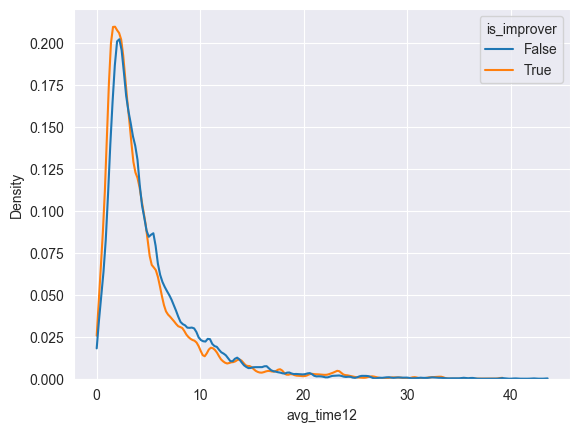

In [205]:
sns.kdeplot(data = person_improve_df,x = 'avg_time12',hue = 'is_improver',common_norm=False,bw_adjust=0.3,cut = 0)

<Axes: xlabel='ans_length', ylabel='Density'>

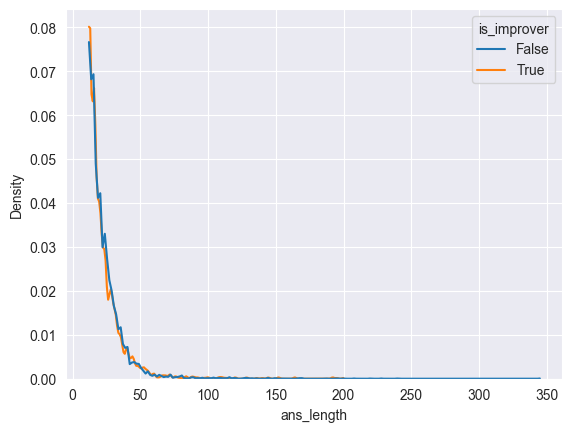

In [206]:
sns.kdeplot(data = person_improve_df,x = 'ans_length',hue = 'is_improver',common_norm=False,bw_adjust=0.3,cut = 0)

<Axes: xlabel='ans_length', ylabel='avg_time12'>

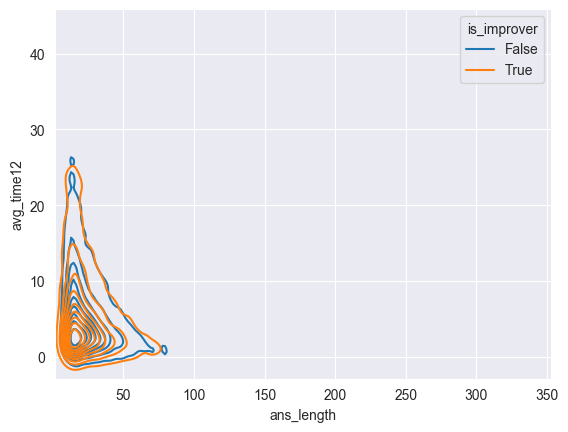

In [207]:
sns.kdeplot(data = person_improve_df,x = 'ans_length',y = 'avg_time12',hue = 'is_improver',common_norm=False,bw_adjust=0.8)

In [208]:
person_improve_long_df = person_improve_df[['first18_time','is_improver']].copy()
for col in range(11):
    person_improve_long_df[f'{col+2}'] = person_improve_df['first18_time'].apply(lambda lis:  lis[col])
person_improve_long_df = person_improve_long_df.drop('first18_time',axis = 1)
person_improve_long_df = person_improve_long_df.fillna(-1)

<Figure size 700x1400 with 0 Axes>

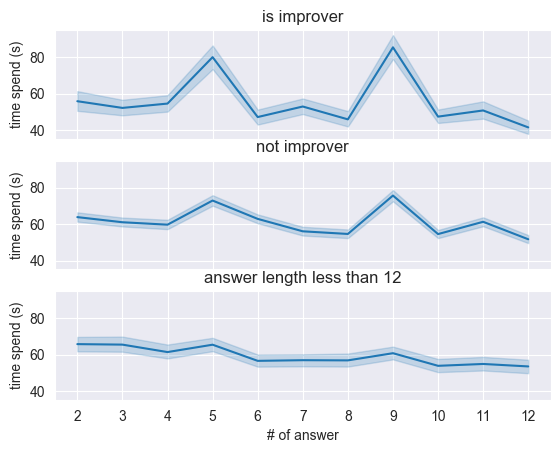

In [209]:
import matplotlib as mpl
plt.figure(figsize=(7,14))
fig,axs = plt.subplots(3,1,sharey= True,sharex=True)
tempdf = person_improve_long_df.melt(id_vars=['is_improver'])
for cate,ax in zip([1,0,-1],axs):
    sns.lineplot(data = tempdf.query(f"is_improver == {cate}"), x = 'variable',y = 'value',ax=ax)
    ax.set_title(f"{'is improver' if cate == 1 else ('not improver' if cate == 0 else 'answer length less than 12') }")
    ax.set_ylabel('time spend (s)')
    ax.set_xlabel('# of answer')


Text(0.5, 0, 'question index')

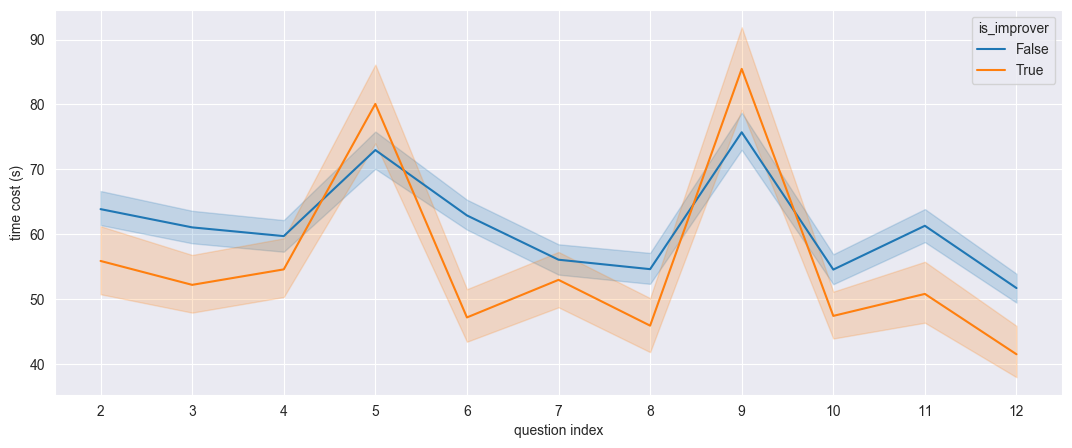

In [210]:
fig = plt.figure(figsize=(13,5))
sns.lineplot(data = tempdf.query('is_improver != -1'), x = 'variable',y = 'value',hue = 'is_improver')
plt.ylabel('time cost (s)')
plt.xlabel('question index')

### analyze the start time distribution

In [211]:
person_improve_df['start_hour'] = person_improve_df['start_time'].dt.hour
person_improve_df['end_hour'] = person_improve_df['end_time'].dt.hour
person_improve_df['start_weekday'] = person_improve_df['start_time'].dt.weekday
person_improve_df['end_weekday'] = person_improve_df['end_time'].dt.weekday

<Axes: xlabel='start_hour', ylabel='Proportion'>

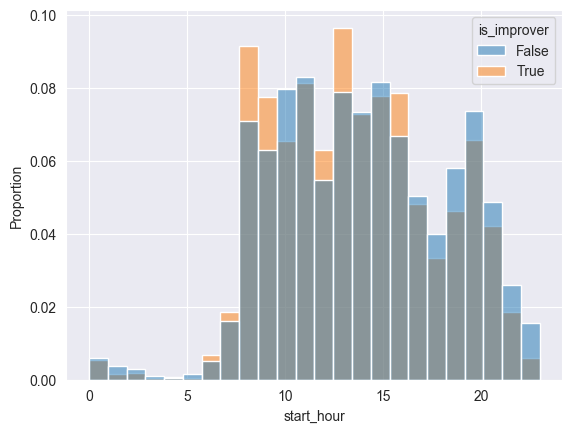

In [212]:
sns.histplot(data = person_improve_df,x = 'start_hour',hue='is_improver',stat='proportion',multiple='layer',common_norm=False,bins = 24)

<Axes: xlabel='end_hour', ylabel='Proportion'>

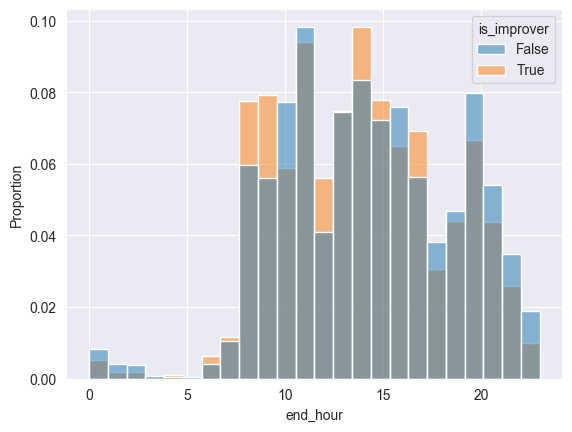

In [213]:
sns.histplot(data = person_improve_df,x = 'end_hour',hue='is_improver',stat='proportion',multiple='layer',common_norm=False,bins = 24)

<Axes: xlabel='start_hour', ylabel='avg_time12'>

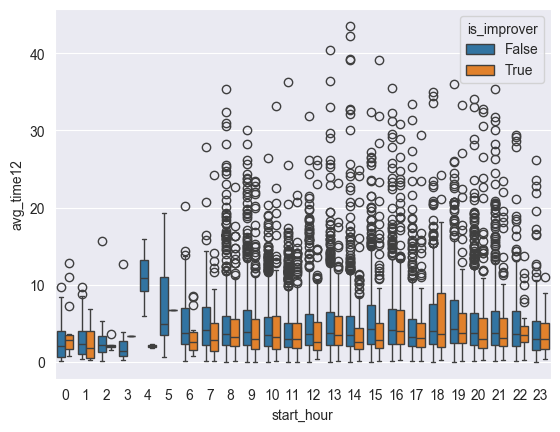

In [214]:
sns.boxplot(data=person_improve_df,x = 'start_hour',y='avg_time12',hue='is_improver')

<Axes: xlabel='start_weekday', ylabel='Proportion'>

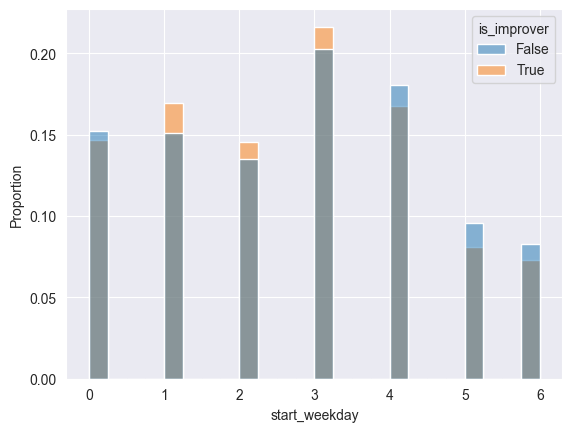

In [215]:
sns.histplot(data=person_improve_df,x='start_weekday',hue='is_improver',stat='proportion',multiple='layer',common_norm=False)

<Axes: xlabel='start_weekday', ylabel='avg_time12'>

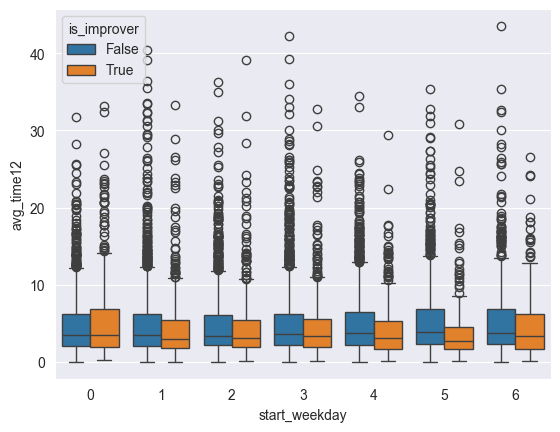

In [216]:
sns.boxplot(data=person_improve_df,x = 'start_weekday',y='avg_time12',hue='is_improver')

In [226]:
person_improve_df

,user_id,section_name,session_id,thetas,ans_length,total_time,first18_time,start_time,end_time,improve,avg_time12,avg_time,is_improver,start_hour,end_hour,start_weekday,end_weekday
0,-9221365525345808910,1 小數的加減,1.0,"[-0.07564564049243927, 0.054245442152023315, 0...",16,"[30, 37, 144, 55, 120, 24, 24, 33, 56, 31, 63,...","[30, 37, 144, 55, 120, 24, 24, 33, 56, 31, 63,...",2023-09-27 08:28:25,2023-09-27 08:41:25,-0.209634,4.333333,3.466667,False,8,8,2,2
1,-9221365525345808910,1 小數的加減,2.0,"[1.1471483707427979, 1.129656434059143, 1.1382...",28,"[18, 50, 60, 39, 70, 36, 57, 19, 88, 43, 70, 5...","[18, 50, 60, 39, 70, 36, 57, 19, 88, 43, 70, 5...",2023-10-06 08:07:44,2023-10-06 08:30:43,0.474174,3.911765,1.891632,False,8,8,4,4
2,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,2.0,"[-1.0722087621688843, -2.3938357830047607, -1....",28,"[51, 34, 28, 91, 38, 18, 30, 41, 60, 43, 99, 1...","[51, 34, 28, 91, 38, 18, 30, 41, 60, 43, 99, 1...",2023-10-13 08:15:51,2023-10-13 08:40:01,0.816612,4.029412,1.989026,False,8,8,4,4
3,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,3.0,"[-0.7606346011161804, -0.769055187702179, -0.1...",31,"[103, 69, 49, 74, 28, 19, 73, 12, 13, 16, 22, ...","[103, 69, 49, 74, 28, 19, 73, 12, 13, 16, 22, ...",2023-10-25 08:20:15,2023-10-25 08:37:52,0.327212,3.715686,1.174444,False,8,8,2,2
4,-9221365525345808910,2+3 因數與公因數、倍數與公倍數,6.0,"[-0.6711925268173218, -0.619068443775177, -1.1...",15,"[29, 68, 13, 29, 62, 79, 14, 158, 67, 15, 69, ...","[29, 68, 13, 29, 62, 79, 14, 158, 67, 15, 69, ...",2023-12-14 08:29:40,2023-12-14 08:40:32,0.580819,3.880952,3.326531,False,8,8,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16371,9223131428943628703,1 多位小數與加減,5.0,"[-0.6645689606666565, 0.47404366731643677, 0.8...",15,"[18, 183, 34, 36, 82, 62, 289, 116, 86, 181, 1...","[18, 183, 34, 36, 82, 62, 289, 116, 86, 181, 1...",2024-02-10 17:44:05,2024-02-10 18:05:46,1.711953,7.744048,6.637755,False,17,18,5,5
16372,9223131428943628703,1 多位小數與加減,6.0,"[-0.3539576530456543, -0.5161980390548706, -0....",14,"[103, 147, 327, 8, 174, 13, 266, 574, 132, 90,...","[103, 147, 327, 8, 174, 13, 266, 574, 132, 90,...",2024-02-13 04:16:19,2024-02-13 04:50:33,1.220504,13.166667,12.153846,False,4,4,1,1
16373,9223131428943628703,2+3 因數與公因數、倍數與公倍數,6.0,"[0.41399097442626953, 0.8116462230682373, 1.33...",13,"[38, 11, 21, 318, 60, 203, 29, 46, 86, 206, 15...","[38, 11, 21, 318, 60, 203, 29, 46, 86, 206, 15...",2024-02-10 17:41:44,2024-02-10 18:01:04,-0.200962,8.055556,8.055556,False,17,18,5,5
16374,9223131428943628703,2+3 因數與公因數、倍數與公倍數,8.0,"[-1.3058608770370483, -1.6766035556793213, -0....",22,"[25, 17, 26, 14, 48, 8, 7, 161, 11, 266, 115, ...","[25, 17, 26, 14, 48, 8, 7, 161, 11, 266, 115, ...",2024-02-13 04:16:05,2024-02-13 04:51:56,2.432317,9.132353,4.877551,False,4,4,1,1


<Axes: xlabel='session_id', ylabel='Proportion'>

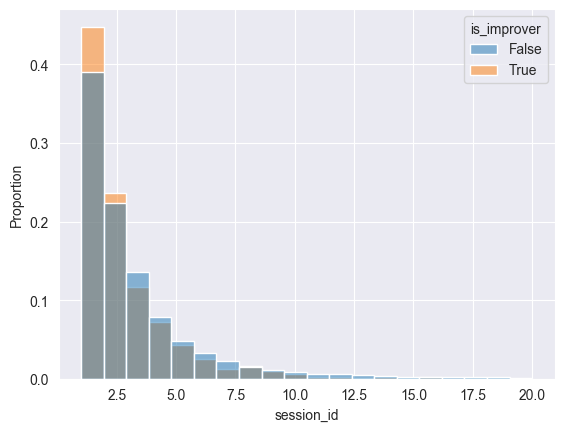

In [225]:
sns.histplot(data = person_improve_df.query("session_id <= 20"),x = 'session_id',hue='is_improver',stat='proportion',multiple='layer',common_norm=False,bins=20)

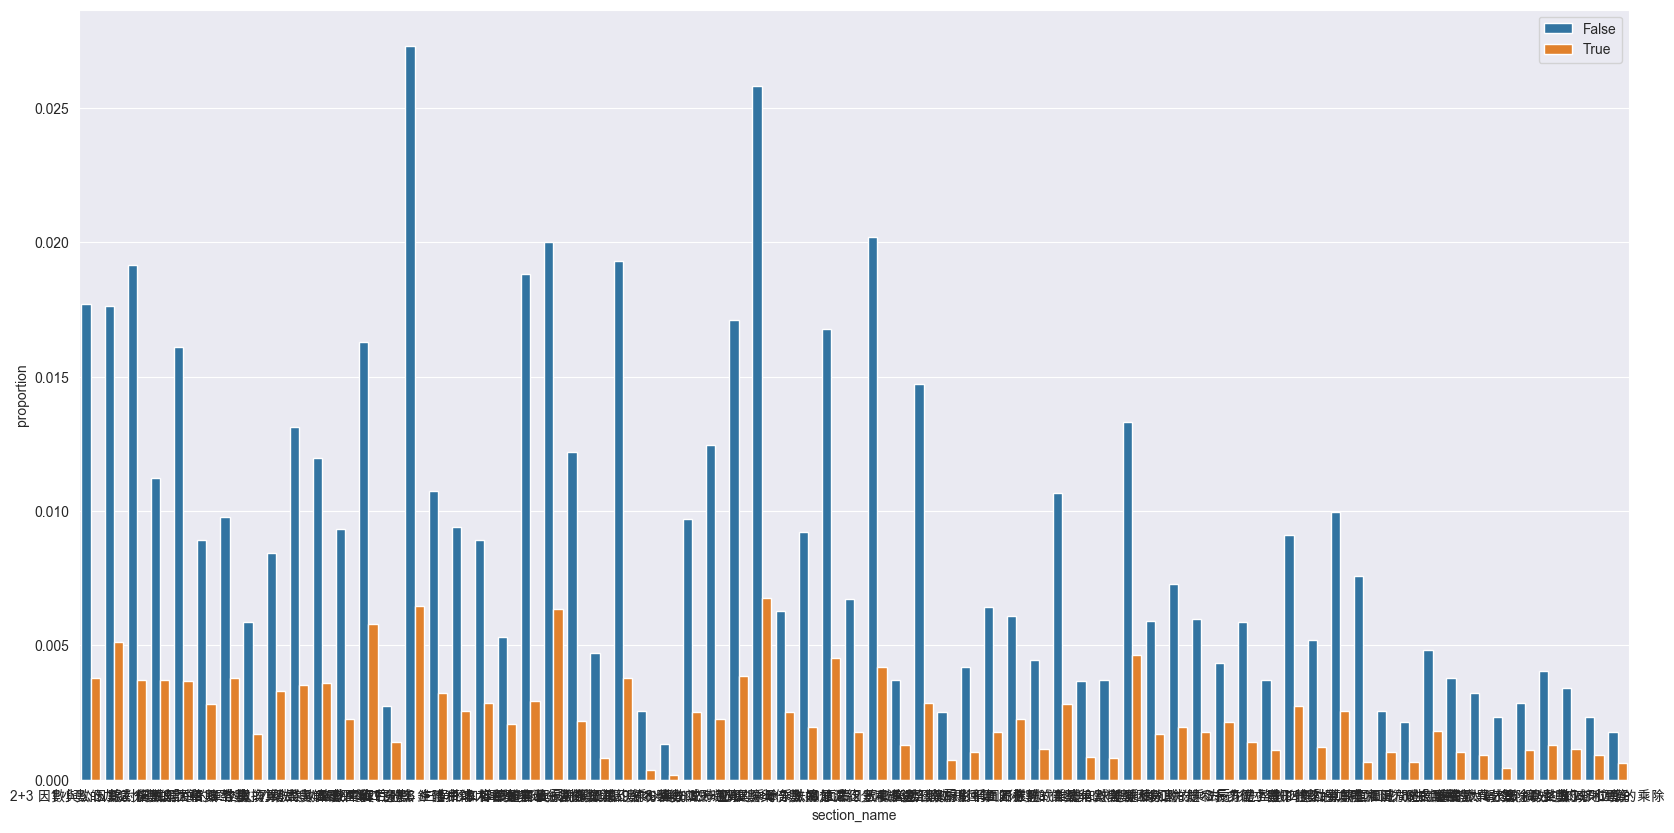

In [243]:
plt.figure(figsize=(20,10))
sns.countplot(data=person_improve_df,x = 'section_name',hue='is_improver',orient="x",stat='proportion')
plt.legend(loc='upper right')

# section based analyze

In [217]:
improve_df_section = wide.groupby('section_name').agg(
    Num_of_section = ('is_improve', 'count'),
    Num_of_improve = ('is_improve', lambda lis: sum(1 for _ in lis if _ > 0))
).reset_index()
improve_df_section

,section_name,Num_of_section,Num_of_improve
0,1 乘法和除法,170,8
1,1 分數,96,3
2,1 分數的乘法,189,8
3,1 多位小數,185,8
4,1 多位小數與加減,302,15
...,...,...,...
62,9 乘以幾分之一,37,2
63,9 容積和容量,152,4
64,9 時間的乘除,382,17
65,9 比率與百分率,451,21


In [218]:
improve_df_section.loc[:,'ratio_of_improvement'] = improve_df_section.apply(lambda row : row['Num_of_improve']/row['Num_of_section'],axis = 1)


Text(0.5, 0, 'ratio of improve')

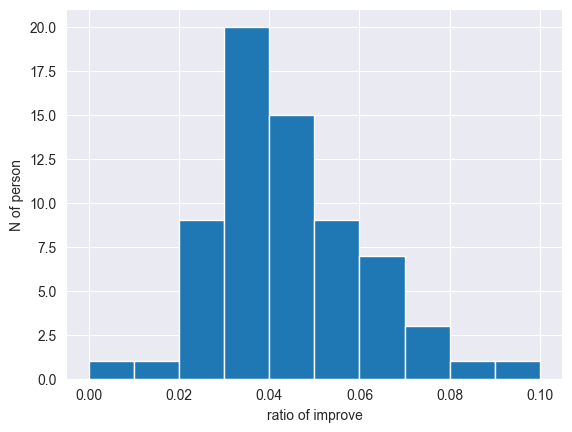

In [219]:

improve_df_section.query('Num_of_section > 2')['ratio_of_improvement'].hist(bins = 10)
plt.ylabel('N of person')
plt.xlabel('ratio of improve')

In [220]:
improve_df_section

,section_name,Num_of_section,Num_of_improve,ratio_of_improvement
0,1 乘法和除法,170,8,0.047059
1,1 分數,96,3,0.031250
2,1 分數的乘法,189,8,0.042328
3,1 多位小數,185,8,0.043243
4,1 多位小數與加減,302,15,0.049669
...,...,...,...,...
62,9 乘以幾分之一,37,2,0.054054
63,9 容積和容量,152,4,0.026316
64,9 時間的乘除,382,17,0.044503
65,9 比率與百分率,451,21,0.046563


<Axes: xlabel='ratio_of_improvement', ylabel='Num_of_section'>

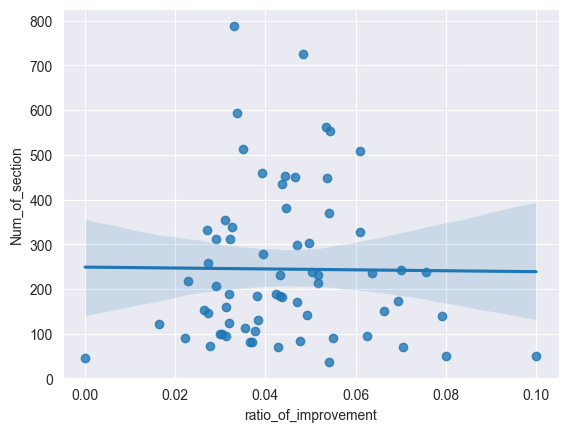

In [221]:
sns.regplot(data=improve_df_section,x = 'ratio_of_improvement',y='Num_of_section')

# Export data to fit stan model